# DAY2 개선 실험 — 피처 정규화·강건 검증·모델 최적화

**목표:** 이전 Elastic Net의 Batch2 MAPE 25.642%를 줄이고 과제 목표 9.1%와 비교한다. Batch1 학습·Batch2 평가, 기존 36/39개 확정 라벨과 정책 분할을 유지한다. Batch3 테스트와 보고서 생성은 하지 않는다.

**읽는 순서:** 가공 입력 → 피처·모델 비교 → 용량 기준 변화 검증 → 보완 피처 → 최종 성능·해석. 각 셀에는 실제 실행 결과가 저장된다. 원본이나 이전 02·03 결과는 덮어쓰지 않는다.

**평가 이력:** Batch2는 이전 분석과 이번 각 라운드에서 이미 확인했다. 라운드 안의 모델 선택은 개발용 CV로 수행하지만, 전체 과정은 탐색적 재분석이며 새 독립 테스트가 아니다. 목표를 맞추려고 정답에 맞춘 보정이나 오류 셀 제거를 하지 않는다.


## 1 입력·라벨·초기 피처와 정책 분할
**목적:** 입력의 기준값 차이와 초기 변화량을 구분한다. 초기 QD 자체를 쓰는 피처와 초기 QD로 나눈 상대 피처, 구간 중앙값을 쓴 피처를 비교한다. ΔQ 최솟값에서 평균을 빼 곡선의 상수 수준 차이에 덜 민감한 피처도 만든다.
**결과:** B1 28개 개발 셀 / 8개 Hold-out, B2 39셀과 평균 피처 표. 정답 결측은 채우지 않는다. 동일 정책이 학습·검증에 겹치지 않는지 확인한다.

In [1]:
# 역할: 기존과 같은 라벨·정책 분할을 사용하고 초기 100사이클 피처를 새로 비교한다.
from pathlib import Path
import hashlib,json,time,warnings
import numpy as np,pandas as pd,matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import GroupShuffleSplit,GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.linear_model import Ridge,ElasticNet,HuberRegressor,QuantileRegressor
from sklearn.svm import SVR
from sklearn.ensemble import ExtraTreesRegressor,HistGradientBoostingRegressor
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_percentage_error,mean_absolute_error,mean_squared_error
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore',category=ConvergenceWarning)
SEED=42;TARGET=9.1
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'processed/day1_final_features.csv').exists())
OUT=ROOT/'output/day2_optimization';OUT.mkdir(parents=True,exist_ok=True)
raw=pd.read_csv(ROOT/'processed/day1_final_features.csv')
raw=raw[raw.batch.isin(['Batch1','Batch2'])].copy()
assert not raw.duplicated(['batch','cell_id']).any()
# 기존 Q100-Q10 추출값을 유지하고, 상수 이동에 덜 민감한 중심화 최솟값과 형태도 비교한다.
raw['dq_log_min']=np.log10(abs(raw.delta_q_min).clip(lower=1e-12))
raw['dq_log_centered_min']=np.log10(abs(raw.delta_q_min-raw.delta_q_mean).clip(lower=1e-12))
raw['dq_log_range']=np.log10((raw.delta_q_max-raw.delta_q_min).clip(lower=1e-12))
raw['dq_log_absmean']=np.log10(raw.delta_q_abs_mean.clip(lower=1e-12))
raw['dq_shape_ratio']=(raw.delta_q_mean-raw.delta_q_min)/raw.delta_q_std.clip(lower=1e-12)
rows=[];summary_hashes={}
for batch,f in [('Batch1','batch1_summary.csv.gz'),('Batch2','batch2_summary.csv.gz')]:
 p=ROOT/'processed'/f;summary_hashes[f]=hashlib.sha256(p.read_bytes()).hexdigest()
 ss=pd.read_csv(p)
 for cid,g in ss.groupby('cell_id'):
  e=g[g.cycle.between(2,100)].sort_values('cycle')
  q2=float(e.loc[e.cycle.eq(2),'QD'].iloc[0]);qmax=float(e.QD.max())
  q10=float(e[e.cycle.between(2,10)].QD.median());qend=float(e[e.cycle.between(91,100)].QD.median())
  slope=float(np.polyfit(e.cycle,e.QD,1)[0]);temp=e.Tavg;ir=e.IR
  rows.append({'batch':batch,'cell_id':cid,'qd_cycle2':q2,'qd_max_minus_cycle2':qmax-q2,
    'qd_slope_cycle2_100':slope,'qd_rel_gain':(qmax-q2)/q2,'qd_rel_slope':slope/q2,
    'qd_window_rel_change':(qend-q10)/q10,'qd_window_change':qend-q10,
    'qd_rel_std':e.QD.std()/q10,'temp_rise':e[e.cycle>=91].Tavg.median()-e[e.cycle<=10].Tavg.median(),
    'ir_rel_change':(e[e.cycle>=91].IR.median()-e[e.cycle<=10].IR.median())/max(e[e.cycle<=10].IR.median(),1e-8)})
raw=raw.merge(pd.DataFrame(rows),on=['batch','cell_id'],validate='one_to_one')
raw['dq_log_variance_relative']=raw.delta_q_log_variance-2*np.log10(raw.qd_cycle2)
raw['dq_log_min_relative']=raw.dq_log_min-np.log10(raw.qd_cycle2)
valid=raw[np.isfinite(raw.cycle_life)&raw.cycle_life.gt(0)].copy()
b1=valid[valid.batch.eq('Batch1')].reset_index(drop=True);b2=valid[valid.batch.eq('Batch2')].reset_index(drop=True)
assert len(b1)==36 and len(b2)==39
tr,va=next(GroupShuffleSplit(n_splits=1,test_size=.25,random_state=SEED).split(b1,groups=b1.charging_policy))
b1['split']='development';b1.loc[va,'split']='holdout'
dev=b1.iloc[tr].reset_index(drop=True);hold=b1.iloc[va].reset_index(drop=True)
# 기존 노트북과 같은 셀 순서로 개발 세트를 구성한다.
dev=b1[b1.split.eq('development')].reset_index(drop=True);hold=b1[b1.split.eq('holdout')].reset_index(drop=True)
assert len(dev)==28 and len(hold)==8 and set(dev.charging_policy).isdisjoint(hold.charging_policy)
folds=list(GroupKFold(n_splits=4).split(dev,groups=dev.charging_policy))
for tr,va in folds:assert set(dev.iloc[tr].charging_policy).isdisjoint(dev.iloc[va].charging_policy)
raw.to_csv(OUT/'optimization_inputs.csv',index=False)
b1[['cell_id','charging_policy','split']].to_csv(OUT/'batch1_split.csv',index=False)
print('입력·분할:',len(dev),'development /',len(hold),'holdout /',len(b2),'Batch2')
display(raw.groupby('batch').agg(total=('cell_id','size'),labels=('cycle_life','count')))
display(valid.groupby('batch')[['delta_q_log_variance','qd_cycle2','qd_rel_gain','qd_rel_slope']].mean())


,total,labels
batch,,
Batch1,46,36
Batch2,47,39


,delta_q_log_variance,qd_cycle2,qd_rel_gain,qd_rel_slope
batch,,,,
Batch1,-3.790902,1.077941,0.004513,-0.000009
Batch2,-3.596276,1.093512,0.006450,0.000005


입력·분할: 28 development / 8 holdout / 39 Batch2


## 2 여러 개선 방법의 후보를 먼저 정의
**목적:** 용량 정규화, 피처 하나씩 제거, Huber의 큰 오차 영향 완화, 역수명 가중 회귀·중앙값 회귀, 비선형·PLS를 같은 조건으로 비교한다.
역수명 가중 절대오차는 MAPE와 연결되지만 가중 제곱오차나 로그 학습은 MAPE 자체와 같지 않다. 그래서 최종 지표는 항상 원래 사이클의 MAPE다.
**결과:** 637개 설정과 비교 규칙. 후보 정의를 파일로 기록한다.

In [2]:
# 역할: Batch2 정답을 보지 않고 피처 조합·정규화·모델·학습 목적의 후보를 정의한다.
v='delta_q_log_variance';m='dq_log_min';cm='dq_log_centered_min'
FS={
 'original5':[v,m,'qd_cycle2','qd_max_minus_cycle2','qd_slope_cycle2_100'],
 'variance':[v],'delta2':[v,m],'delta_centered':[v,cm],
 'delta_shape':[v,'dq_log_range','dq_shape_ratio'],
 'delta_relative':['dq_log_variance_relative','dq_log_min_relative'],
 'relative_capacity':[v,m,'qd_rel_gain','qd_rel_slope'],
 'window_capacity':[v,m,'qd_window_rel_change','qd_rel_std'],
 'delta_temp':[v,m,'temp_rise'],
 'delta_ir':[v,m,'ir_rel_change'],
 'delta_current':[v,m,'charge_I_qw_100'],
 'delta_charge':[v,m,'chargetime_mean_100'],
 'delta_mean':[v,'dq_log_absmean'],
}
# 기존 5개에서 하나씩 빼서 각 변수의 추가 효과를 비교한다.
for f in FS['original5']:FS['drop_'+f]=[c for c in FS['original5'] if c!=f]
specs=[]
def add(model,fs,target='log10',weight='none',**params):
 specs.append({'id':f'{model}_{len(specs):04d}','model':model,'feature_set':fs,'target':target,'weight':weight,'params':params})
for fs in FS:
 for a in [.001,.01,.1,1.,10.,100.]:add('Ridge',fs,alpha=a)
 for a in [.0001,.001,.01]:
  for ratio in [.1,.5,.9]:add('ElasticNet',fs,alpha=a,l1_ratio=ratio)
 for a in [.001,.01,.1,1.]:add('Ridge',fs,'raw','inverse_y',alpha=a)
 for epsilon in [1.1,1.35,1.7]:add('Huber',fs,epsilon=epsilon,alpha=.01)
 for a in [.001,.01,.1]:add('Quantile',fs,'raw','inverse_y',alpha=a,quantile=.5)
 for C in [.03,.1,.3,1.]:add('SVR',fs,C=C,epsilon=.005)
 for a in [.1,1.,10.]:add('PolynomialRidge',fs,alpha=a)
 for n in [1,2]:
  if n<=len(FS[fs]):add('PLS',fs,n_components=n)
# 비선형 트리의 설정 범위를 먼저 고정한다.
for fs in ['delta2','relative_capacity','window_capacity','delta_current','original5']:
 for depth in [2,4,None]:add('ExtraTrees',fs,max_depth=depth,min_samples_leaf=3)
 for leaf in [3,5]:add('HistGB',fs,max_leaf_nodes=7,min_samples_leaf=leaf,l2_regularization=1.)
# 기존 Elastic Net을 같은 검증 조건의 기준선으로 둔다.
BASE={'id':'Existing_ElasticNet','model':'ElasticNet','feature_set':'original5','target':'log10','weight':'none','params':{'alpha':.001,'l1_ratio':.5}}
specs.append(BASE)
for fs in FS:
 assert set(FS[fs]).isdisjoint({'cycle_life','provided_cycle_life','observed_cycles','knee_cycle_candidate','cell_id','charging_policy'})
# 최저 CV+1%p 안의 단순 후보는 보조 비교다. 이 라운드의 주 후보는 최소 CV다.
PLAN={'selection_rule':'development 4-group CV mean MAPE minimum; ties std then fewer features',
 'simple_secondary_rule':'within 1 percentage point of best CV, minimum features then CV',
 'holdout_and_test_not_used_for_selection':True,'prior_test_inspection':True,'n_candidates':len(specs),
 'seed':42,'features':FS,'candidates':specs,'input_hash':hashlib.sha256((ROOT/'processed/day1_final_features.csv').read_bytes()).hexdigest(),
 'summary_hashes':summary_hashes}
(OUT/'experiment_plan.json').write_text(json.dumps(PLAN,ensure_ascii=False,indent=2))
def make(s):
 p=s['params'];name=s['model']
 if name=='Ridge' or name=='PolynomialRidge':model=Ridge(**p)
 elif name=='ElasticNet':model=ElasticNet(**p,max_iter=50000)
 elif name=='Huber':model=HuberRegressor(**p,max_iter=2000)
 elif name=='Quantile':model=QuantileRegressor(**p,solver='highs')
 elif name=='SVR':model=SVR(**p,kernel='rbf',gamma='scale')
 elif name=='PLS':model=PLSRegression(**p,scale=False)
 elif name=='ExtraTrees':model=ExtraTreesRegressor(**p,n_estimators=100,random_state=42,n_jobs=1)
 elif name=='HistGB':model=HistGradientBoostingRegressor(**p,max_iter=100,learning_rate=.03,random_state=42)
 else:raise ValueError(name)
 steps=[('impute',SimpleImputer(strategy='median')),('scale',StandardScaler())]
 if name=='PolynomialRidge':steps += [('poly',PolynomialFeatures(degree=2,include_bias=False)),('poly_scale',StandardScaler())]
 return Pipeline(steps+[('model',model)])
def fit(s,frame):
 model=make(s);y=frame.cycle_life.to_numpy();target=np.log10(y) if s['target']=='log10' else y
 kwargs={}
 if s['weight']=='inverse_y':kwargs['model__sample_weight']=(1/y)/(1/y).mean()
 model.fit(frame[FS[s['feature_set']]],target,**kwargs);return model
def predict(model,s,frame):
 p=np.asarray(model.predict(frame[FS[s['feature_set']]])).ravel()
 return 10.**p if s['target']=='log10' else p

def score(y,p):
 assert np.isfinite(p).all() and (p>0).all(),'invalid positive lifetime predictions'
 e=p-np.asarray(y)
 return {'MAPE':float(np.mean(abs(e)/y)*100),'MAE':float(np.mean(abs(e))),'RMSE':float(np.sqrt(np.mean(e**2))),
 'bias':float(np.mean(e)),'over_pct':float(np.mean(e>0)*100),'max_over':float(np.max(e))}
print('비교 후보:',len(specs),'피처 조합:',len(FS))


비교 후보: 637 피처 조합: 18


## 3 일반 조건 그룹 CV로 비교
**목적:** Hold-out·Batch2로 고르지 않고 개발용 28셀만으로 비교한다.
**결과:** 일반 CV 순위, 최소 CV 후보, 방법별 대표 후보. 많은 후보를 고르면 선택 낙관성이 생길 수 있으며 전체 탐색의 nested CV를 수행한 것은 아니다.

In [3]:
# 역할: 개발용 28셀로만 비교한다. Hold-out/Test는 이 단계에서 예측하지 않는다.
cv_rows=[];fold_rows=[];failed=[];by_id={s['id']:s for s in specs};start=time.perf_counter()
for i,s in enumerate(specs,1):
 vals=[]
 for k,(tr,va) in enumerate(folds,1):
  try:
   model=fit(s,dev.iloc[tr]);p=predict(model,s,dev.iloc[va]);z=score(dev.iloc[va].cycle_life.to_numpy(),p)
   vals.append(z['MAPE']);fold_rows.append({'id':s['id'],'fold':k,**z})
  except (ValueError,AssertionError,np.linalg.LinAlgError) as e:
   failed.append({'id':s['id'],'fold':k,'error':str(e)});break
 if len(vals)==4:cv_rows.append({'id':s['id'],'model':s['model'],'feature_set':s['feature_set'],'target':s['target'],'weight':s['weight'],'features':len(FS[s['feature_set']]),'CV_MAPE':np.mean(vals),'CV_std':np.std(vals,ddof=1)})
 if i%100==0:print(i,'/',len(specs),'CV 후보 완료')
cv_results=pd.DataFrame(cv_rows).sort_values(['CV_MAPE','CV_std','features']).reset_index(drop=True)
cv_results.to_csv(OUT/'cv_candidates.csv',index=False);pd.DataFrame(fold_rows).to_csv(OUT/'cv_fold_scores.csv',index=False);pd.DataFrame(failed).to_csv(OUT/'failed_candidates.csv',index=False)
chosen=by_id[cv_results.iloc[0].id]
simple_result=cv_results[cv_results.CV_MAPE<=cv_results.iloc[0].CV_MAPE+1.].sort_values(['features','CV_MAPE']).iloc[0]
simple=by_id[simple_result.id]
# 외부 평가 전에 주 후보·단순 후보·개선 방법별 대표를 CV로 고정한다.
representatives=[]
for label,mask in [
 ('feature_ablation',cv_results.feature_set.str.startswith('drop_')),
 ('capacity_normalization',cv_results.feature_set.isin(['relative_capacity','window_capacity','delta_relative'])),
 ('robust_regression',cv_results.model.eq('Huber')),
 ('MAPE_aligned',cv_results.weight.eq('inverse_y')),
 ('nonlinear',cv_results.model.isin(['SVR','PolynomialRidge','ExtraTrees','HistGB'])),
 ('delta_only',cv_results.feature_set.eq('delta2'))]:
 subset=cv_results[mask]
 if len(subset):representatives.append({'method':label,'id':subset.iloc[0].id})
FROZEN={'winner':chosen,'simple_secondary':simple,'method_representatives':representatives,'baseline':BASE,'chosen_before_external_predictions':True,'prior_batch2_already_inspected':True}
(OUT/'selection_frozen.json').write_text(json.dumps(FROZEN,ensure_ascii=False,indent=2))
display(cv_results.head(15));print('CV 최소 후보:',chosen,'CV 시간:',round(time.perf_counter()-start,1))


,id,model,feature_set,target,weight,features,CV_MAPE,CV_std
0,ElasticNet_0451,ElasticNet,drop_delta_q_log_variance,log10,none,4,4.775085,1.718423
1,ElasticNet_0010,ElasticNet,original5,log10,none,5,4.775134,1.718035
2,Existing_ElasticNet,ElasticNet,original5,log10,none,5,4.775134,1.718035
3,Ridge_0595,Ridge,drop_qd_slope_cycle2_100,raw,inverse_y,4,4.866559,2.094345
4,ElasticNet_0587,ElasticNet,drop_qd_slope_cycle2_100,log10,none,4,4.926844,1.425316
5,ElasticNet_0588,ElasticNet,drop_qd_slope_cycle2_100,log10,none,4,4.948082,1.396925
6,ElasticNet_0011,ElasticNet,original5,log10,none,5,4.975081,1.448988
7,ElasticNet_0452,ElasticNet,drop_delta_q_log_variance,log10,none,4,4.975100,1.449240
8,Ridge_0003,Ridge,original5,log10,none,5,4.993773,1.938976
9,ElasticNet_0453,ElasticNet,drop_delta_q_log_variance,log10,none,4,5.016880,1.451359


100 / 637 CV 후보 완료
200 / 637 CV 후보 완료
300 / 637 CV 후보 완료
400 / 637 CV 후보 완료
500 / 637 CV 후보 완료
600 / 637 CV 후보 완료
CV 최소 후보: {'id': 'ElasticNet_0451', 'model': 'ElasticNet', 'feature_set': 'drop_delta_q_log_variance', 'target': 'log10', 'weight': 'none', 'params': {'alpha': 0.001, 'l1_ratio': 0.5}} CV 시간: 7.6


## 4 첫 라운드에서 고정한 후보 평가
**목적:** CV 기준 후보와 방법별 대표를 고정한 뒤 Hold-out·Batch2에 적용한다. 테스트 순위로 교체하지 않는다.
**결과:** 일반 CV 최소 후보는 기존 25.642%를 25.639%로 거의 개선하지 못한다. 상대 용량 피처 Ridge는 19.390%지만 일반 CV는 나쁘므로 추가 검증 없이 테스트 점수만으로 최종으로 정하지 않는다.

In [4]:
# 역할: CV로 고정한 후보만 Hold-out과 Batch2에 평가한다. 최저 Test 후보로 최종을 바꾸지 않는다.
import cloudpickle
ids=list(dict.fromkeys([BASE['id'],chosen['id'],simple['id']]+[z['id'] for z in representatives]))
evals=[];preds=[];models={}
for sid in ids:
 s=by_id[sid];cr=cv_results[cv_results.id.eq(sid)].iloc[0]
 hm=fit(s,dev);hp=predict(hm,s,hold);hs=score(hold.cycle_life.to_numpy(),hp)
 fm=fit(s,b1);bp=predict(fm,s,b2);bs=score(b2.cycle_life.to_numpy(),bp);models[sid]=fm
 evals.append({'id':sid,'model':s['model'],'feature_set':s['feature_set'],'CV_MAPE':cr.CV_MAPE,'CV_std':cr.CV_std,'Valid_MAPE':hs['MAPE'],'Test_MAPE':bs['MAPE'],'Test_RMSE':bs['RMSE'],'Test_MAE':bs['MAE'],'bias':bs['bias'],'max_over':bs['max_over'],'over_pct':bs['over_pct']})
 for ds,f,p in [('Holdout',hold,hp),('Batch2',b2,bp)]:
  for cid,y,pp in zip(f.cell_id,f.cycle_life,p):preds.append({'id':sid,'dataset':ds,'cell_id':cid,'actual':y,'predicted':pp,'APE_pct':abs(pp-y)/y*100})
results=pd.DataFrame(evals);results.to_csv(OUT/'frozen_candidate_evaluation.csv',index=False)
pd.DataFrame(preds).to_csv(OUT/'predictions.csv',index=False)
display(results.round(3))
w=results[results.id.eq(chosen['id'])].iloc[0]
report=pd.DataFrame([
 ['Train (Batch 1 CV)',w.CV_MAPE,'development group CV'],['Valid (Batch 1 Hold-out)',w.Valid_MAPE,'fixed policy holdout'],['Test (Batch 2)',w.Test_MAPE,'all 39 labeled cells'],
 ['Gap (Train-Valid)',w.Valid_MAPE-w.CV_MAPE,'Valid - CV (%p)'],['Gap (Valid-Test)',w.Test_MAPE-w.Valid_MAPE,'Test - Valid (%p)'],['Gap (Target-Test)',w.Test_MAPE-TARGET,'Test - 9.1 (%p)']],columns=['구분','MAPE (%)','비고'])
report.to_csv(OUT/'performance_reporting.csv',index=False,encoding='utf-8-sig');display(report.round({'MAPE (%)':3}))
with (OUT/'selected_model.pkl').open('wb') as f:cloudpickle.dump({'model':models[chosen['id']],'spec':chosen,'features':FS[chosen['feature_set']]},f)
with (OUT/'selected_model.pkl').open('rb') as f:restored=cloudpickle.load(f)
# 명시적인 행 선택으로 저장 예측과 일치하는지 확인한다.
pr=pd.DataFrame(preds);saved=pr[pr.id.eq(chosen['id'])&pr.dataset.eq('Batch2')]
np.testing.assert_allclose(predict(restored['model'],restored['spec'],b2),saved.predicted)
base=results[results.id.eq(BASE['id'])].iloc[0]
np.testing.assert_allclose([base.CV_MAPE,base.Valid_MAPE,base.Test_MAPE],[4.775134352081155,5.694733210468472,25.642498635652842],rtol=1e-8)
(OUT/'verification.json').write_text(json.dumps({'policy_overlap':0,'old_baseline_reproduced':True,'saved_model_predictions_match':True,'no_batch3':True,'test_n':39,'target_achieved':bool(w.Test_MAPE<=TARGET)},indent=2))
print('CV 선택 모델의 Batch2:',w.Test_MAPE,'목표와의 차이:',w.Test_MAPE-TARGET)


,id,model,feature_set,CV_MAPE,CV_std,Valid_MAPE,Test_MAPE,Test_RMSE,Test_MAE,bias,max_over,over_pct
0,Existing_ElasticNet,ElasticNet,original5,4.775,1.718,5.695,25.642,223.144,155.607,144.247,763.328,87.179
1,ElasticNet_0451,ElasticNet,drop_delta_q_log_variance,4.775,1.718,5.693,25.639,223.148,155.596,144.216,763.384,87.179
2,Ridge_0206,Ridge,relative_capacity,6.582,2.806,5.361,19.390,172.451,118.793,74.314,613.186,76.923
3,Huber_0462,Huber,drop_delta_q_log_variance,5.023,1.471,5.678,25.752,227.606,157.318,144.731,782.563,87.179
4,Ridge_0595,Ridge,drop_qd_slope_cycle2_100,4.867,2.094,6.579,22.230,163.154,125.456,90.033,487.528,82.051
5,PolynomialRidge_0607,PolynomialRidge,drop_qd_slope_cycle2_100,6.582,2.416,6.039,32.606,230.911,181.445,38.060,598.059,61.538
6,Quantile_0091,Quantile,delta2,8.151,1.675,11.268,26.254,145.975,132.250,106.773,271.253,87.179


,구분,MAPE (%),비고
0,Train (Batch 1 CV),4.775,development group CV
1,Valid (Batch 1 Hold-out),5.693,fixed policy holdout
2,Test (Batch 2),25.639,all 39 labeled cells
3,Gap (Train-Valid),0.918,Valid - CV (%p)
4,Gap (Valid-Test),19.947,Test - Valid (%p)
5,Gap (Target-Test),16.539,Test - 9.1 (%p)


CV 선택 모델의 Batch2: 25.639171968268133 목표와의 차이: 16.539171968268136


## 5 용량 기준값 변화에 견디는지 검증
**목적:** 측정 QD에 상수 오프셋이 더해져도 실제 수명이 같다는 가정 아래 예측 민감도를 확인한다. 고정 오프셋 0, ±0.015, ±0.030 Ah를 각 개발 검증 fold에 적용해 평균 MAPE로 비교한다. 학습 데이터 증강도 각 학습 fold 안에서만 수행한다.
**결과:** 일반 CV와 가상 조건 CV를 구분한다. 기존 모델의 가상 조건 CV는 14.161%, 상대 피처 Ridge는 6.602%다. 이 라운드 기준의 최선은 상대 피처 Ridge이다.
**한계:** 첫 라운드의 Batch2 결과를 이미 확인한 뒤 정한 개발 가정이다. 가상 오프셋은 실제 센서 오차로 확정된 값이 아니며 실제 운영 위험을 입증하지 않는다.

In [5]:
# 역할: 초기 용량의 측정 기준이 조금 달라져도 예측이 유지되는 모델을 찾는다.
# 물리적 가정: QD에 상수 오프셋이 더해지면 용량 차이·기울기는 같고 초기값은 달라진다.
# 0, ±0.015, ±0.030 Ah를 미리 정한다. Batch2 정답으로 이 값을 조절하지 않는다.
OFFSETS=[-.03,-.015,0.,.015,.03]
def capacity_offset(frame,d):
 f=frame.copy();q=frame.qd_cycle2
 f['qd_cycle2']=q+d
 f['qd_rel_gain']=frame.qd_max_minus_cycle2/(q+d)
 f['qd_rel_slope']=frame.qd_slope_cycle2_100/(q+d)
 # window 피처는 초기 구간 중앙값 기준이므로 여기서 근사 변환하지 않는다.
 # 초기 용량을 분모로 쓰는 상대 ΔQ만 다시 계산한다.
 f['dq_log_variance_relative']=frame.delta_q_log_variance-2*np.log10(q+d)
 f['dq_log_min_relative']=frame.dq_log_min-np.log10(q+d)
 return f
# 용량 기준 이동을 명확히 적용할 수 있는 조합만 가상 조건 검증에 사용한다.
STRESS_FS={'original5','variance','delta2','delta_centered','delta_shape','delta_relative',
 'relative_capacity','delta_temp','delta_ir','delta_current','delta_charge','delta_mean',
 *[name for name in FS if name.startswith('drop_')]}
# 완료된 일반 CV 후보만 사용하며 비정상 예측 후보는 제외한다.
robust_specs=[by_id[sid] for sid in cv_results.id if by_id[sid]['feature_set'] in STRESS_FS]
# 데이터 증강: 같은 셀에 용량 오프셋을 더하고 정답은 유지한다. 각 학습 fold 안에서만 수행한다.
augmented=[]
for fs in ['original5','drop_delta_q_log_variance','relative_capacity']:
 for name in ['Ridge','ElasticNet','Huber']:
  for a in [.01,.1,1.,10.]:
   if name=='Ridge':params={'alpha':a}
   elif name=='ElasticNet':params={'alpha':a/100,'l1_ratio':.5}
   else:params={'alpha':a/100,'epsilon':1.35}
   sid='Aug_'+name+'_'+fs+'_'+str(a)
   s={'id':sid,'model':name,'feature_set':fs,'target':'log10','weight':'none','params':params,'augment':True}
   augmented.append(s);by_id[sid]=s
robust_specs+=augmented
ROBUST_PLAN={'offsets_Ah':OFFSETS,'selection_metric':'mean over 4 policy folds and 5 fixed capacity offsets',
 'interpretation':'hypothetical constant calibration offset robustness; not observed failure probability',
 'training_augmentation':'only outer train cells, identical target, offsets from fixed list',
 'candidate_count':len(robust_specs),'previous_batch2_inspection':True,'test_not_used_for_current_selection':True}
(OUT/'robust_plan.json').write_text(json.dumps(ROBUST_PLAN,ensure_ascii=False,indent=2))
def robust_fit(s,frame):
 if not s.get('augment'):return fit(s,frame)
 return fit(s,pd.concat([capacity_offset(frame,d) for d in OFFSETS],ignore_index=True))
robust_rows=[];stress_rows=[];rfailed=[]
for i,s in enumerate(robust_specs,1):
 vals=[];normal=[]
 for k,(tr,va) in enumerate(folds,1):
  try:
   model=robust_fit(s,dev.iloc[tr]);vv=[]
   for d in OFFSETS:
    z=score(dev.iloc[va].cycle_life.to_numpy(),predict(model,s,capacity_offset(dev.iloc[va],d)))
    vv.append(z['MAPE']);stress_rows.append({'id':s['id'],'fold':k,'capacity_offset':d,**z})
    if d==0.:normal.append(z['MAPE'])
   vals.append(np.mean(vv))
  except (AssertionError,ValueError,np.linalg.LinAlgError) as e:rfailed.append({'id':s['id'],'fold':k,'error':str(e)});break
 if len(vals)==4:robust_rows.append({'id':s['id'],'model':s['model'],'feature_set':s['feature_set'],'augment':s.get('augment',False),'CV_MAPE':np.mean(normal),'Robust_CV':np.mean(vals),'Robust_std':np.std(vals,ddof=1)})
 if i%150==0:print('robust CV:',i,'/',len(robust_specs))
robust_cv=pd.DataFrame(robust_rows).sort_values(['Robust_CV','Robust_std']).reset_index(drop=True)
robust_cv.to_csv(OUT/'robust_cv_candidates.csv',index=False);pd.DataFrame(stress_rows).to_csv(OUT/'stress_fold_scores.csv',index=False)
robust_chosen=by_id[robust_cv.iloc[0].id]
(OUT/'robust_selection_frozen.json').write_text(json.dumps({'winner':robust_chosen,'criterion':ROBUST_PLAN,'test_not_used_for_selection':True},ensure_ascii=False,indent=2))
display(robust_cv.head(12))
# 이 라운드의 주 후보를 고정한 뒤 추가 외부 예측을 수행한다.
rm=robust_fit(robust_chosen,dev);rp=predict(rm,robust_chosen,hold);rh=score(hold.cycle_life.to_numpy(),rp)
rf=robust_fit(robust_chosen,b1);rtp=predict(rf,robust_chosen,b2);rt=score(b2.cycle_life.to_numpy(),rtp)
ROBUST_RESULT={'spec':robust_chosen,'CV_MAPE':float(robust_cv.iloc[0].CV_MAPE),'robust_CV':float(robust_cv.iloc[0].Robust_CV),'Valid_MAPE':rh['MAPE'],'Test_MAPE':rt['MAPE'],'Test_RMSE':rt['RMSE'],'Test_MAE':rt['MAE'],'bias':rt['bias'],'max_over':rt['max_over'],'over_pct':rt['over_pct']}
(OUT/'robust_result.json').write_text(json.dumps(ROBUST_RESULT,ensure_ascii=False,indent=2))
pd.DataFrame({'cell_id':b2.cell_id,'actual':b2.cycle_life,'predicted':rtp,'APE_pct':abs(rtp-b2.cycle_life)/b2.cycle_life*100}).to_csv(OUT/'robust_predictions_batch2.csv',index=False)
with (OUT/'robust_model.pkl').open('wb') as f:cloudpickle.dump({'model':rf,'spec':robust_chosen,'features':FS[robust_chosen['feature_set']]},f)
print('robust criterion selected:',ROBUST_RESULT)


,id,model,feature_set,augment,CV_MAPE,Robust_CV,Robust_std
0,Ridge_0206,Ridge,relative_capacity,False,6.581981,6.601830,2.775216
1,Aug_ElasticNet_drop_delta_q_log_variance_0.1,ElasticNet,drop_delta_q_log_variance,True,6.682166,6.759780,2.197844
2,Aug_Ridge_original5_1.0,Ridge,original5,True,6.682406,6.786422,2.391280
3,Ridge_0512,Ridge,drop_qd_cycle2,False,6.786698,6.786698,2.748051
4,Aug_Ridge_drop_delta_q_log_variance_1.0,Ridge,drop_delta_q_log_variance,True,6.736675,6.811980,2.173386
5,Aug_Ridge_relative_capacity_10.0,Ridge,relative_capacity,True,6.831723,6.853972,2.847122
6,Aug_Ridge_original5_10.0,Ridge,original5,True,6.711395,6.856910,2.683883
7,Aug_Huber_drop_delta_q_log_variance_10.0,Huber,drop_delta_q_log_variance,True,6.723776,6.861200,1.962821
8,Aug_Huber_drop_delta_q_log_variance_1.0,Huber,drop_delta_q_log_variance,True,6.724401,6.861883,1.962025
9,Aug_Huber_drop_delta_q_log_variance_0.1,Huber,drop_delta_q_log_variance,True,6.724435,6.861922,1.961979


robust CV: 150 / 634
robust CV: 300 / 634
robust CV: 450 / 634
robust CV: 600 / 634
robust criterion selected: {'spec': {'id': 'Ridge_0206', 'model': 'Ridge', 'feature_set': 'relative_capacity', 'target': 'log10', 'weight': 'none', 'params': {'alpha': 1.0}}, 'CV_MAPE': 6.581981343582073, 'robust_CV': 6.601829698499939, 'Valid_MAPE': 5.361468852904552, 'Test_MAPE': 19.38950744383301, 'Test_RMSE': 172.45090628344295, 'Test_MAE': 118.79259025115577, 'bias': 74.31363915889776, 'max_over': 613.1863846975275, 'over_pct': 76.92307692307693}


## 6 상대 피처·중심화 ΔQ와 초기 신호를 추가 비교
**목적:** 같은 용량 기준 검증 규칙 아래 중심화 ΔQ, 초기 전류·온도 변화·충전 조건 등 180개 설정을 보완 비교한다.
**결과:** 중심화 ΔQ와 상대 용량 변화 피처를 사용하는 Ridge(alpha=1)가 일반 CV 6.214%, 가상 조건 CV 6.249%로 선택된다. Batch2는 20.176%다.
상대 피처 Ridge의 19.390%보다 Test가 높지만 검증 기준이 개선돼 정한 기준대로 선택한다. 최저 Test를 보고 선택하는 방식은 사용하지 않는다.

In [6]:
# 역할: 상대 용량 피처에 초기 전류·온도 변화·충전 조건을 더해보는 마지막 비교다.
# 첫 두 라운드의 외부 결과를 확인한 뒤의 탐색임을 기록한다. 새 독립 테스트가 아니다.
EXT_FS={
 'relative_temp':[v,m,'qd_rel_gain','qd_rel_slope','temp_rise'],
 'relative_current':[v,m,'qd_rel_gain','qd_rel_slope','charge_I_qw_100'],
 'relative_charge':[v,m,'qd_rel_gain','qd_rel_slope','chargetime_mean_100'],
 'relative_soc':[v,m,'qd_rel_gain','qd_rel_slope','switch_soc'],
 'relative_protocol':[v,m,'qd_rel_gain','qd_rel_slope','first_c_rate','second_c_rate','switch_soc'],
 'protocol':[v,m,'first_c_rate','second_c_rate','switch_soc'],
 'current_soc':[v,m,'charge_I_qw_100','switch_soc'],
 'centered_relative':[v,cm,'qd_rel_gain','qd_rel_slope'],
 'variance_relative_gain':[v,'qd_rel_gain'],
 'variance_relative_slope':[v,'qd_rel_slope'],
 'min_relative':[m,'qd_rel_gain','qd_rel_slope'],
 'delta_temperature':[v,m,'tavg_mean_100','temp_rise'],
}
FS.update(EXT_FS);extension_specs=[]
for fs in EXT_FS:
 for alpha in [.01,.1,1.,10.,100.]:
  for target,weight in [('log10','none'),('raw','inverse_y')]:
   s={'id':f'Ext_Ridge_{len(extension_specs):03d}','model':'Ridge','feature_set':fs,'target':target,'weight':weight,'params':{'alpha':alpha}}
   extension_specs.append(s);by_id[s['id']]=s
 for alpha in [.0001,.001,.01,.1]:
  s={'id':f'Ext_EN_{len(extension_specs):03d}','model':'ElasticNet','feature_set':fs,'target':'log10','weight':'none','params':{'alpha':alpha,'l1_ratio':.5}}
  extension_specs.append(s);by_id[s['id']]=s
 s={'id':f'Ext_Huber_{len(extension_specs):03d}','model':'Huber','feature_set':fs,'target':'log10','weight':'none','params':{'alpha':.01,'epsilon':1.35}}
 extension_specs.append(s);by_id[s['id']]=s
(OUT/'extension_plan.json').write_text(json.dumps({'features':EXT_FS,'specs':extension_specs,'selection_rule':ROBUST_PLAN,'previous_external_results_already_seen':True},ensure_ascii=False,indent=2))
more=[]
for s in extension_specs:
 normal=[];vals=[]
 for tr,va in folds:
  try:
   model=fit(s,dev.iloc[tr]);vs=[]
   for d in OFFSETS:
    val=score(dev.iloc[va].cycle_life.to_numpy(),predict(model,s,capacity_offset(dev.iloc[va],d)))['MAPE'];vs.append(val)
    if d==0:normal.append(val)
   vals.append(np.mean(vs))
  except (ValueError,AssertionError,np.linalg.LinAlgError):break
 if len(vals)==4:more.append({'id':s['id'],'model':s['model'],'feature_set':s['feature_set'],'augment':False,'CV_MAPE':np.mean(normal),'Robust_CV':np.mean(vals),'Robust_std':np.std(vals,ddof=1)})
ext_cv=pd.DataFrame(more);ext_cv.to_csv(OUT/'extension_cv.csv',index=False)
combined=pd.concat([robust_cv,ext_cv]).sort_values(['Robust_CV','Robust_std']).reset_index(drop=True)
combined.to_csv(OUT/'combined_robust_cv.csv',index=False);final_spec=by_id[combined.iloc[0].id]
FINAL_SELECTION={'spec':final_spec,'criterion':ROBUST_PLAN,'final_feature_sets':FS,'prior_external_inspection':True,'this_round_choice_uses_only_development_CV':True}
(OUT/'final_selection_frozen.json').write_text(json.dumps(FINAL_SELECTION,ensure_ascii=False,indent=2))
display(combined.head(12))
final_hm=robust_fit(final_spec,dev);final_hp=predict(final_hm,final_spec,hold);final_h=score(hold.cycle_life.to_numpy(),final_hp)
final_fm=robust_fit(final_spec,b1);final_tp=predict(final_fm,final_spec,b2);final_t=score(b2.cycle_life.to_numpy(),final_tp)
FINAL_RESULT={'spec':final_spec,'CV_MAPE':float(combined.iloc[0].CV_MAPE),'robust_CV':float(combined.iloc[0].Robust_CV),'Valid_MAPE':final_h['MAPE'],'Test_MAPE':final_t['MAPE'],'Test_RMSE':final_t['RMSE'],'Test_MAE':final_t['MAE'],'bias':final_t['bias'],'max_over':final_t['max_over'],'over_pct':final_t['over_pct']}
(OUT/'final_result.json').write_text(json.dumps(FINAL_RESULT,ensure_ascii=False,indent=2))
for ds,ff,pp in [('holdout',hold,final_hp),('batch2',b2,final_tp)]:
 pd.DataFrame({'cell_id':ff.cell_id,'actual':ff.cycle_life,'predicted':pp,'APE_pct':abs(pp-ff.cycle_life)/ff.cycle_life*100}).to_csv(OUT/f'final_predictions_{ds}.csv',index=False)
with (OUT/'final_optimized_model.pkl').open('wb') as f:cloudpickle.dump({'model':final_fm,'spec':final_spec,'features':FS[final_spec['feature_set']]},f)
print('FINAL_RESULT:',FINAL_RESULT)


,id,model,feature_set,augment,CV_MAPE,Robust_CV,Robust_std
0,Ext_Ridge_109,Ridge,centered_relative,False,6.213971,6.249315,3.083456
1,Ext_Ridge_034,Ridge,relative_charge,False,6.375317,6.390677,2.412089
2,Ext_Ridge_049,Ridge,relative_soc,False,6.359461,6.395863,2.659162
3,Ext_Ridge_154,Ridge,min_relative,False,6.559827,6.572746,2.769244
4,Ext_EN_116,ElasticNet,centered_relative,False,6.587421,6.601600,2.677426
5,Ridge_0206,Ridge,relative_capacity,False,6.581981,6.601830,2.775216
6,Aug_ElasticNet_drop_delta_q_log_variance_0.1,ElasticNet,drop_delta_q_log_variance,True,6.682166,6.759780,2.197844
7,Aug_Ridge_original5_1.0,Ridge,original5,True,6.682406,6.786422,2.391280
8,Ridge_0512,Ridge,drop_qd_cycle2,False,6.786698,6.786698,2.748051
9,Aug_Ridge_drop_delta_q_log_variance_1.0,Ridge,drop_delta_q_log_variance,True,6.736675,6.811980,2.173386


FINAL_RESULT: {'spec': {'id': 'Ext_Ridge_109', 'model': 'Ridge', 'feature_set': 'centered_relative', 'target': 'log10', 'weight': 'none', 'params': {'alpha': 1.0}}, 'CV_MAPE': 6.213971181976687, 'robust_CV': 6.249314742316647, 'Valid_MAPE': 4.611457417136553, 'Test_MAPE': 20.17552900701508, 'Test_RMSE': 173.91146508719038, 'Test_MAE': 122.29781636485629, 'bias': 84.9683310824177, 'max_over': 631.280902131075, 'over_pct': 76.92307692307693}


## 7 최신 성능 양식·오류·저장 검증
**목적:** 최신 모델의 필수 6행 성능표와 이전 모델 대비 개선, 큰 오류·입력 차이를 함께 확인한다.
**결과:** 최종 MAPE 20.176%, RMSE 173.91사이클. 저장 모델을 복원해 CSV 예측과 같은지 확인한다. 그림의 점선 위는 수명 과대예측이다.

,구분,MAPE (%),비고
0,Train (Batch 1 CV),6.214,일반 조건 그룹 CV; 모델 선택은 별도 용량 기준 검증
1,Valid (Batch 1 Hold-out),4.611,고정 정책 그룹 Hold-out
2,Test (Batch 2),20.176,확정 수명 39셀; 반복 확인한 탐색 평가
3,Gap (Train-Valid),-1.603,Valid - CV (%p)
4,Gap (Valid-Test),15.564,Test - Valid (%p)
5,Gap (Target-Test),11.076,Test - 9.1 (%p)


,version,CV_MAPE,Valid_MAPE,Test_MAPE,Test_RMSE,Robust_CV
0,Previous ElasticNet,4.775,5.695,25.642,223.144,14.161
1,Ordinary CV winner,4.775,5.693,25.639,223.148,NaN
2,Relative Ridge,6.582,5.361,19.390,172.451,6.602
3,Final centered Ridge,6.214,4.611,20.176,173.911,6.249


,feature,B1_mean,B2_mean,B1_min,B1_max,B2_outside_count
0,delta_q_log_variance,-3.790902,-3.596276,-4.178878,-3.350338,17
1,dq_log_centered_min,-1.670505,-1.598486,-1.850631,-1.467721,16
2,qd_rel_gain,0.004513,0.006450,0.002885,0.008978,20
3,qd_rel_slope,-0.000009,0.000005,-0.000130,0.000027,18


,cell_id,actual,predicted,APE_pct,charging_policy
36,44,841.0,1472.280902,75.063127,5.2C(58%)-4C-newstructure
9,9,791.0,1213.150368,53.369200,5.6C(26%)-4.5C-newstructure
13,13,460.0,660.758332,43.643116,4.65C(69%)-6C
17,17,471.0,270.458084,42.577902,5.6C(26%)-4.5C
2,2,424.0,595.462767,40.439332,5.2C(50%)-4.25C


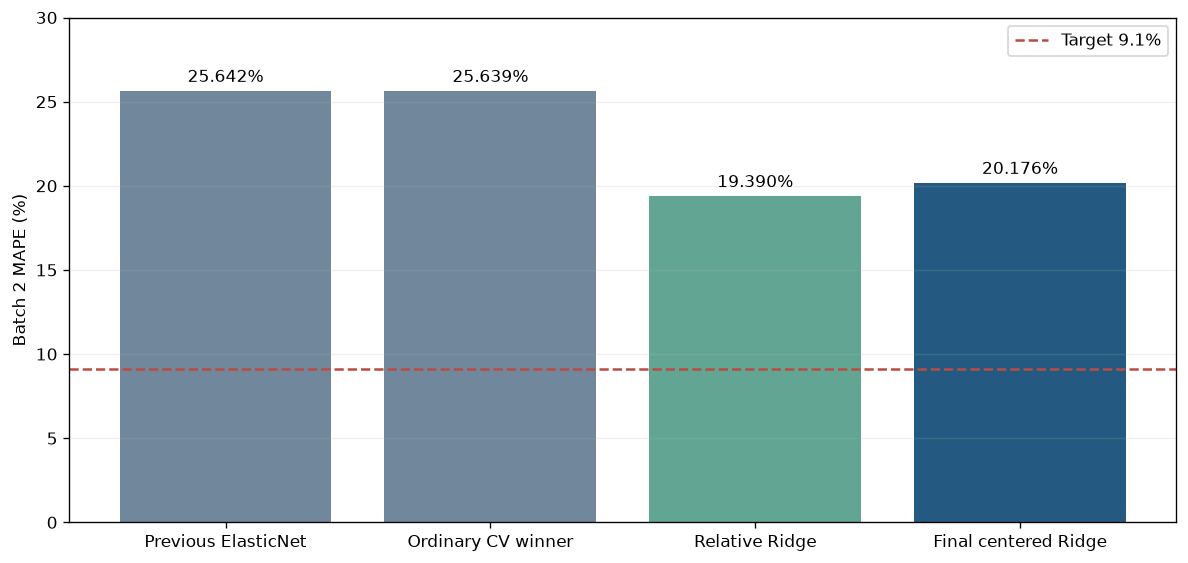

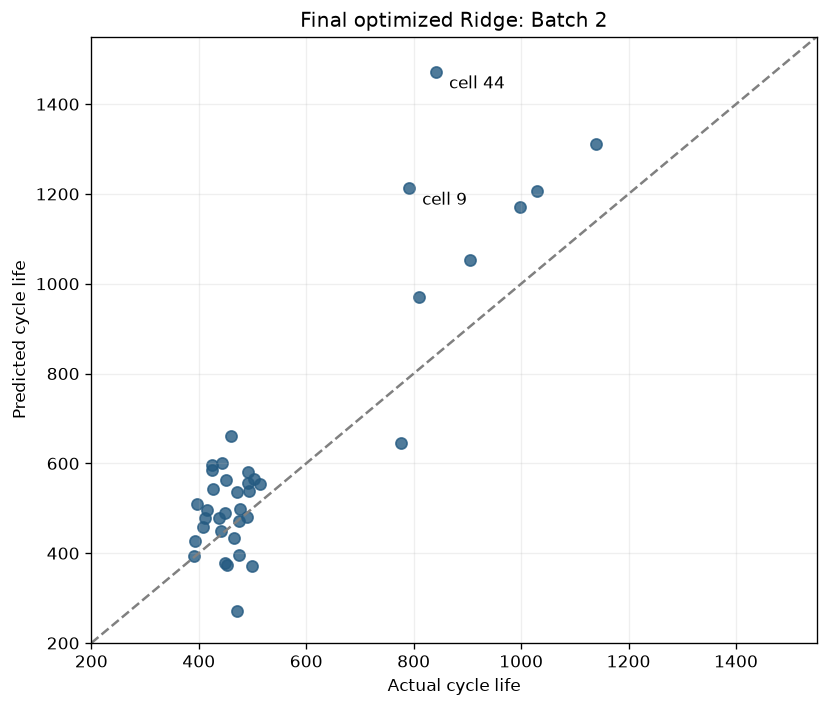

최종 MAPE 개선: 5.467 %p; 목표 잔여 차이: 11.076 %p
용량 기준 변화 검증은 가상 측정 오프셋 가정이다. 실제 ESS 성능이나 독립 테스트를 보장하지 않는다.
최저 Batch2 후보를 최종으로 고르지 않았고, 목표 미달도 그대로 보고한다.


In [ ]:
# 역할: 최신 모델의 과제 양식·오류·검증 결과를 저장하고 그림으로 비교한다.
w=FINAL_RESULT
final_report=pd.DataFrame([
 ['Train (Batch 1 CV)',w['CV_MAPE'],'일반 조건 그룹 CV; 모델 선택은 별도 용량 기준 검증'],
 ['Valid (Batch 1 Hold-out)',w['Valid_MAPE'],'고정 정책 그룹 Hold-out'],
 ['Test (Batch 2)',w['Test_MAPE'],'확정 수명 39셀; 반복 확인한 탐색 평가'],
 ['Gap (Train-Valid)',w['Valid_MAPE']-w['CV_MAPE'],'Valid - CV (%p)'],
 ['Gap (Valid-Test)',w['Test_MAPE']-w['Valid_MAPE'],'Test - Valid (%p)'],
 ['Gap (Target-Test)',w['Test_MAPE']-TARGET,'Test - 9.1 (%p)']],columns=['구분','MAPE (%)','비고'])
final_report.to_csv(OUT/'performance_reporting.csv',index=False,encoding='utf-8-sig')
display(final_report.round({'MAPE (%)':3}))
compare=pd.DataFrame([
 {'version':'Previous ElasticNet','CV_MAPE':base.CV_MAPE,'Valid_MAPE':base.Valid_MAPE,'Test_MAPE':base.Test_MAPE,'Test_RMSE':base.Test_RMSE,'Robust_CV':float(robust_cv[robust_cv.id.eq(BASE['id'])].iloc[0].Robust_CV)},
 {'version':'Ordinary CV winner','CV_MAPE':float(results[results.id.eq(chosen['id'])].iloc[0].CV_MAPE),'Valid_MAPE':float(results[results.id.eq(chosen['id'])].iloc[0].Valid_MAPE),'Test_MAPE':float(results[results.id.eq(chosen['id'])].iloc[0].Test_MAPE),'Test_RMSE':float(results[results.id.eq(chosen['id'])].iloc[0].Test_RMSE)},
 {'version':'Relative Ridge','CV_MAPE':ROBUST_RESULT['CV_MAPE'],'Valid_MAPE':ROBUST_RESULT['Valid_MAPE'],'Test_MAPE':ROBUST_RESULT['Test_MAPE'],'Test_RMSE':ROBUST_RESULT['Test_RMSE'],'Robust_CV':ROBUST_RESULT['robust_CV']},
 {'version':'Final centered Ridge','CV_MAPE':w['CV_MAPE'],'Valid_MAPE':w['Valid_MAPE'],'Test_MAPE':w['Test_MAPE'],'Test_RMSE':w['Test_RMSE'],'Robust_CV':w['robust_CV']},
])
compare.to_csv(OUT/'revision_comparison.csv',index=False);display(compare.round(3))
cols=FS[final_spec['feature_set']]
shifts=[]
for c in cols:
 lo,hi=b1[c].min(),b1[c].max();shifts.append({'feature':c,'B1_mean':b1[c].mean(),'B2_mean':b2[c].mean(),'B1_min':lo,'B1_max':hi,'B2_outside_count':int(((b2[c]<lo)|(b2[c]>hi)).sum())})
pd.DataFrame(shifts).to_csv(OUT/'feature_shift.csv',index=False);display(pd.DataFrame(shifts))
final_errors=pd.read_csv(OUT/'final_predictions_batch2.csv').merge(b2[['cell_id','charging_policy']],on='cell_id',validate='one_to_one')
final_errors.to_csv(OUT/'final_errors.csv',index=False);display(final_errors.sort_values('APE_pct',ascending=False).head(5))
fig,ax=plt.subplots(figsize=(10,4.8));x=np.arange(len(compare));bars=ax.bar(x,compare.Test_MAPE,color=['#71889c','#71889c','#62a592','#245a81']);ax.bar_label(bars,fmt='%.3f%%',padding=3);ax.axhline(TARGET,color='#bb4c43',ls='--',label='Target 9.1%');ax.set_xticks(x,compare.version);ax.set_ylabel('Batch 2 MAPE (%)');ax.set_ylim(0,30);ax.legend();ax.grid(axis='y',alpha=.2);fig.tight_layout();fig.savefig(OUT/'optimization_comparison.png',dpi=180);plt.show()
fig,ax=plt.subplots(figsize=(7,6));ax.scatter(final_errors.actual,final_errors.predicted,color='#245a81',s=45,alpha=.8);lo=200;hi=1550;ax.plot([lo,hi],[lo,hi],'--',color='gray');ax.set(xlim=(lo,hi),ylim=(lo,hi),xlabel='Actual cycle life',ylabel='Predicted cycle life',title='Final optimized Ridge: Batch 2')
for _,z in final_errors.nlargest(2,'APE_pct').iterrows():ax.annotate(f'cell {int(z.cell_id)}',(z.actual,z.predicted),xytext=(8,-10),textcoords='offset points')
ax.grid(alpha=.2);fig.tight_layout();fig.savefig(OUT/'final_actual_predicted.png',dpi=180);plt.show()
# 모델 저장·복원과 CSV 숫자를 직접 대조한다.
with (OUT/'final_optimized_model.pkl').open('rb') as f:restored=cloudpickle.load(f)
np.testing.assert_allclose(predict(restored['model'],restored['spec'],b2),final_errors.predicted,rtol=1e-10)
np.testing.assert_allclose(final_errors.APE_pct.mean(),w['Test_MAPE'],rtol=1e-10)
assert final_spec['id']==combined.iloc[0].id
assert len(final_errors)==39 and not final_errors.cell_id.duplicated().any()
VERIFICATION={'policy_overlap':0,'existing_metrics_reproduced':True,'final_model_restored_predictions_match':True,
 'regular_candidate_count':len(specs),'augmentation_candidate_count':len(augmented),'extension_candidate_count':len(extension_specs),
 'regular_cv_completed':len(cv_results),'robust_cv_completed':len(robust_cv),'extension_cv_completed':len(ext_cv),
 'test_n':39,'test_cells_removed':0,'batch3_test_used':False,'target_achieved':bool(w['Test_MAPE']<=TARGET),
 'final_selection_metric':'hypothetical calibration offset robustness CV','prior_test_history_disclosed':True}
(OUT/'final_verification.json').write_text(json.dumps(VERIFICATION,ensure_ascii=False,indent=2))
print('최종 MAPE 개선:',round(base.Test_MAPE-w['Test_MAPE'],3),'%p; 목표 잔여 차이:',round(w['Test_MAPE']-TARGET,3),'%p')
print('용량 기준 변화 검증은 가상 측정 오프셋 가정이다. 실제 ESS 성능이나 독립 테스트를 보장하지 않는다.')


## 8 최종 해석과 다음 개선

- 기존 모델 대비 MAPE **25.642 → 20.176%**, **5.467%p** 개선(상대 감소 약 21.3%). RMSE **223.14 → 173.91사이클**로 감소했다. 목표 9.1%에는 **11.076%p** 미달이다.
- 주된 변경은 절대 초기 용량 입력을 상대 변화량으로 바꾸고, 가상 용량 오프셋 검증으로 모델을 선택한 것이다. 새 피처·모델·검증 기준이 함께 달라 각 효과를 완전히 분리한 인과 실험은 아니다. 중심화 피처 추가는 CV를 개선했지만 상대 피처만 쓴 Ridge보다 Batch2 MAPE를 개선하지 못했다.
- 최종은 **Ridge(alpha=1), log10 수명**, 입력은 ΔQ 로그분산, ΔQ 중심화 최솟값 로그, 상대 용량 증가량, 상대 용량 기울기 4개다. 이전 Elastic Net보다 일반 CV는 높고 Hold-out·Batch2와 가상 조건 지표는 낮다. 목적에 맞는 검증 기준을 함께 보고한다.
- 여전히 cell44는 실제841 → 약1472, cell9는 실제791 → 약1213으로 큰 과대예측이다. 목표 달성과 운영 적용이 확인된 모델이 아니다.
- 다음은 측정 기준·전압 곡선 정렬과 EOL 정의 대조, 새 단수명·다양한 정책 셀 데이터 확보, 전체 선택 절차의 nested 그룹 CV 또는 새 독립 테스트, 불확실성·과대예측 비용 검증 순서다.
- 원논문 공개 LoadData.m은 2017-06-30 데이터의 연속 실험 연결을 사용한다. 현재 제공 Batch2는 2018-02-20이므로 원문의 연결 인덱스를 그대로 적용해 라벨을 만드는 것은 정당하지 않다. 새 연속 실험 파일이 확보되면 식별자와 실험 이력을 확인한 뒤 검토한다.

원문 데이터 처리 참고: https://github.com/rdbraatz/data-driven-prediction-of-battery-cycle-life-before-capacity-degradation/blob/master/LoadData.m
